In [1]:
import pandas as pd
import numpy as np

In [2]:
df_wd = pd.read_csv("files/world_data_full.csv", index_col=0)
df_wd.head()

,country,density,abbreviation,agricultural_land,land_area,armed_forces_size,birth_rate,calling_code,capital/major_city,co2-emissions,...,out_of_pocket_health_expenditure,physicians_per_thousand,population,population_labor_force_participation,tax_revenue,total_tax_rate,unemployment_rate,urban_population,latitude,longitude
0,Afghanistan,60,AF,58.1,"652,230","323,000",32.49,93.0,Kabul,"8,672",...,78.4,0.28,"38,041,754",48.9,9.3,71.4,11.12,"9,797,273",33.93911,67.709953
1,Albania,105,AL,43.1,"28,748","9,000",11.78,355.0,Tirana,"4,536",...,56.9,1.20,"2,854,191",55.7,18.6,36.6,12.33,"1,747,593",41.153332,20.168331
2,Algeria,18,DZ,17.4,"2,381,741","317,000",24.28,213.0,Algiers,"150,006",...,28.1,1.72,"43,053,054",41.2,37.2,66.1,11.70,"31,510,100",28.033886,1.659626
3,Andorra,164,AD,40.0,468,NaN,7.20,376.0,Andorra la Vella,469,...,36.4,3.33,"77,142",NaN,NaN,NaN,NaN,"67,873",42.506285,1.521801
4,Angola,26,AO,47.5,"1,246,700","117,000",40.73,244.0,Luanda,"34,693",...,33.4,0.21,"31,825,295",77.5,9.2,49.1,6.89,"21,061,025",-11.202692,17.873887


In [3]:
df_wd.info()

<class 'pandas.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 35 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   country                               195 non-null    str    
 1   density                               195 non-null    str    
 2   abbreviation                          188 non-null    str    
 3   agricultural_land                     188 non-null    float64
 4   land_area                             194 non-null    str    
 5   armed_forces_size                     171 non-null    str    
 6   birth_rate                            189 non-null    float64
 7   calling_code                          194 non-null    float64
 8   capital/major_city                    192 non-null    str    
 9   co2-emissions                         188 non-null    str    
 10  cpi                                   178 non-null    str    
 11  cpi_change                    

Ejercicios apply
Las columnas land_area, armed_forces_size, co2-emissions, gdp, population, urban_population, latitude, longitude, density, cpi son de tipo object pero en realidad deberían ser numéricas. Crea una función que nos permita cambiar el tipo de dato de estas columnas al que le corresponde.

Crea una función para añadir una nueva columna llamada 'Continent' al DataFrame para indicar a qué continente pertenece cada país.

Guarda el DataFrame después de los cambios creados después de los dos ejercicios anteriores para usarlo posteriormente.

In [ ]:
def convertir_a_numerico_apply(df, columnas): #"Se utilizó apply() para recorrer cada valor de las columnas y aplicar una función personalizada que limpia y convierte los datos a tipo numérico."
    df = df.copy()
    
    for col in columnas:
        df[col] = df[col].apply(lambda x: limpiar_y_convertir(x))
    
    return df

In [14]:
df_wd[cols_numericas].dtypes

land_area            float64
armed_forces_size    float64
co2-emissions        float64
gdp                  float64
population           float64
urban_population     float64
latitude             float64
longitude            float64
density                int64
cpi                  float64
dtype: object

In [15]:
df_wd['country']

0      Afghanistan
1          Albania
2          Algeria
3          Andorra
4           Angola
          ...     
190      Venezuela
191        Vietnam
192          Yemen
193         Zambia
194       Zimbabwe
Name: country, Length: 195, dtype: str

In [21]:
continentes = {
    'Europe': ['Spain', 'France', 'Germany', 'Italy', 'Albania', 'Andorra'],
    'Asia': ['China', 'India', 'Japan', 'Afghanistan'],
    'Africa': ['Nigeria', 'Algeria', 'Angola'],
    'North America': ['United States', 'Canada', 'Mexico'],
    'South America': ['Brazil', 'Argentina'],
    'Oceania': ['Australia']
}

In [22]:
def asignar_continente(pais):
    for continente, lista_paises in continentes.items():
        if pais in lista_paises:
            return continente
    return 'Unknown'

In [23]:
df_wd['Continent'] = df_wd['country'].apply(asignar_continente)

In [24]:
# Crear dataframe final
df_limpio = df_wd

# Guardarlo
df_limpio.to_csv('df_limpio.csv', index=False)

In [25]:
df_limpio.head(2)

,country,density,abbreviation,agricultural_land,land_area,armed_forces_size,birth_rate,calling_code,capital/major_city,co2-emissions,...,physicians_per_thousand,population,population_labor_force_participation,tax_revenue,total_tax_rate,unemployment_rate,urban_population,latitude,longitude,Continent
0,Afghanistan,60,AF,58.1,652230.0,323000.0,32.49,93.0,Kabul,8672.0,...,0.28,38041754.0,48.9,9.3,71.4,11.12,9797273.0,33.939110,67.709953,Asia
1,Albania,105,AL,43.1,28748.0,9000.0,11.78,355.0,Tirana,4536.0,...,1.20,2854191.0,55.7,18.6,36.6,12.33,1747593.0,41.153332,20.168331,Europe


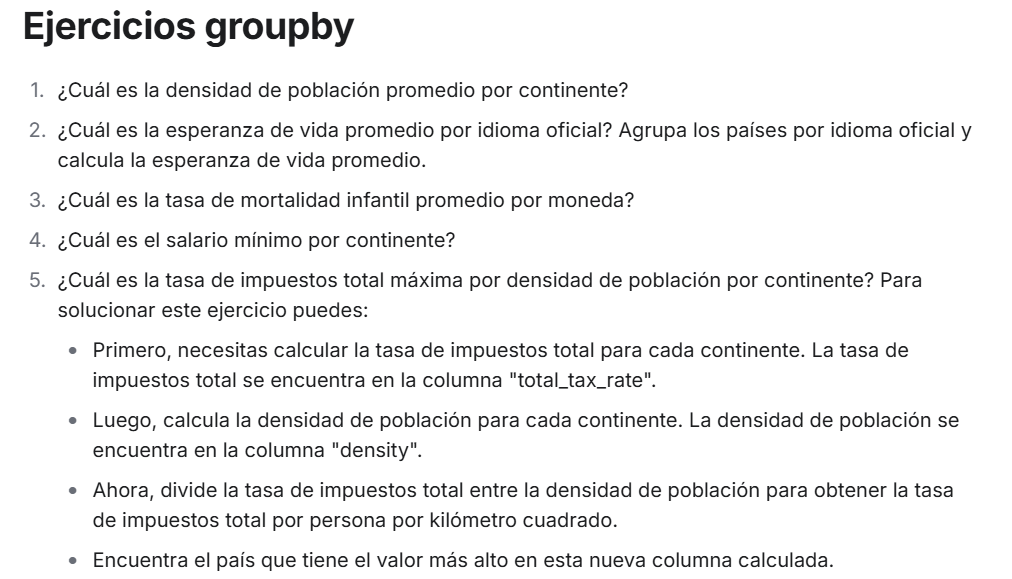

In [29]:
df_limpio.columns

Index(['country', 'density', 'abbreviation', 'agricultural_land', 'land_area',
       'armed_forces_size', 'birth_rate', 'calling_code', 'capital/major_city',
       'co2-emissions', 'cpi', 'cpi_change', 'currency-code', 'fertility_rate',
       'forested_area', 'gasoline_price', 'gdp',
       'gross_primary_education_enrollment',
       'gross_tertiary_education_enrollment', 'infant_mortality',
       'largest_city', 'life_expectancy', 'maternal_mortality_ratio',
       'minimum_wage', 'official_language', 'out_of_pocket_health_expenditure',
       'physicians_per_thousand', 'population',
       'population_labor_force_participation', 'tax_revenue', 'total_tax_rate',
       'unemployment_rate', 'urban_population', 'latitude', 'longitude',
       'Continent'],
      dtype='str')

In [26]:
df_limpio.groupby('Continent')['density'].mean()

Continent
Africa            90.000000
Asia             256.000000
Europe           154.666667
North America     35.333333
Oceania            3.000000
South America     21.000000
Unknown          381.795455
Name: density, dtype: float64

In [27]:
df_limpio.groupby('official_language')['life_expectancy'].mean()

official_language
Afrikaans                 63.900000
Albanian                  78.500000
Amharic                   66.200000
Arabic                    72.864706
Armenian                  74.900000
Azerbaijani language      72.900000
Bengali                   72.300000
Bosnian                   77.300000
Bulgarian                 74.900000
Burmese                   66.900000
Catalan                         NaN
Croatian                  78.100000
Czech                     79.000000
Danish                    81.000000
Divehi                    78.600000
Dutch                     76.700000
Dzongkha                  71.500000
English                   68.879310
Estonian                  78.200000
Fiji Hindi                67.300000
French                    65.495833
Georgian                  73.600000
German                    82.275000
Greek                     81.050000
Hebrew                    82.800000
Hindi                     69.400000
Hungarian                 75.800000
Icelandic 

In [30]:
df_limpio.groupby('currency-code')['infant_mortality'].mean()

currency-code
AED     6.500000
AFN    47.900000
ALL     7.800000
AMD    11.000000
AOA    51.600000
ARS     8.800000
AUD    21.633333
AZN    19.200000
BAM     5.000000
BBD    11.300000
BDT    25.100000
BGN     5.900000
BHD     6.100000
BIF    41.000000
BND     9.800000
BOB    21.800000
BRL    12.800000
BWP    30.000000
BYN     2.600000
BZD    11.200000
CAD     4.300000
CDF    68.200000
CHF     3.700000
CLP     6.200000
CNY     7.400000
COP    12.200000
CRC     7.600000
CUP     3.700000
CVE    16.700000
CZK     2.700000
DJF    49.800000
DKK     3.600000
DOP    24.100000
DZD    20.100000
EGP    18.100000
ERN    31.300000
ETB    39.100000
EUR     2.854545
FJD    21.600000
GBP     3.600000
GEL     8.700000
GHS    34.900000
GMD    39.000000
GNF    64.900000
GTQ    22.100000
GYD    25.100000
HNL    15.100000
HRK     4.000000
HTG    49.500000
HUF     3.600000
IDR    21.100000
ILS     3.000000
INR    29.900000
IQD    22.500000
IRR    12.400000
ISK     1.500000
JMD    12.400000
JOD    13.900000


In [31]:
df_limpio.groupby('Continent')['minimum_wage'].mean()

Continent
Africa            0.733333
Asia              2.092500
Europe            6.900000
North America     5.750000
Oceania          13.590000
South America     2.440000
Unknown           1.881288
Name: minimum_wage, dtype: float64